In [2]:
from tqdm import tqdm
import numpy as np

import mpmath as mp
import sympy as sp
from sympy import *

import scipy.sparse as spmat
import scipy.sparse.linalg as spla

import matplotlib.pyplot as plt

In [3]:
x = symbols('x', real=True)
lam = symbols('lambda', real=True, positive=True)

## Trigonometric Case

In [4]:
def raise_trigonometric(n, psi):
    if n < 0:
        return psi
    result = -I * diff(psi, x) + I * (lam + n) * tan(x) * psi
    return raise_trigonometric(n - 1, result)

def get_aux_ground_state_trigonometric(n):
    norm = sqrt(gamma(lam + n + 1) / (sqrt(pi) * gamma(lam + n + Rational(1, 2))))
    return norm * cos(x)**(lam + n)

def get_wavefunction_raising(n):
    psi_0 = get_aux_ground_state_trigonometric(n)
    norm = sqrt(gamma(2 * lam + n) / (gamma(n+1) * gamma(2 * lam + 2 * n)))
    return (norm * raise_trigonometric(n - 1, psi_0))

In [5]:
def get_wavefunction_hyper(n):
    a = -n
    b = n + 2*lam
    c = lam + Rational(1, 2)
    z = (1 + sin(x)) / 2

    psi = (cos(x)) ** lam * hyper([a, b], [c], z)
    norm = sqrt( (2*(n + lam) * gamma(n + 2*lam))
                 / (factorial(n) * 2**(2*lam) * gamma(lam + Rational(1, 2))**2) )
    return (norm * psi)

def get_wavefunction_jacobi(n):
    norm = sqrt(2 * (n+lam) * gamma(n + 2 * lam) * gamma(n + 1) )/ (2 ** lam * gamma(n + lam + Rational(1, 2)))
    alpha = lam - Rational(1,2)
    psi = (cos(x))**lam * jacobi(n, alpha, alpha, -sin(x))

    return (norm * psi)

In [44]:
mp.mp.dps = 15
mp.mp.prec = mp.mp.dps * 3.33


In [45]:
import mpmath as mp

def V_trig(x, lam):
    return lam*(lam-1)/mp.cos(x)**2 - lam**2

# ODE system
def schrodinger_trig_rhs(x, Y, lam, En):
    psi, psi_p = Y
    dpsi = psi_p
    dpsi_p = (V_trig(x, lam) - En) * psi
    return [dpsi, dpsi_p]

def shooting_trig(n, lam, eps=1e-6):
    En = n*(2*lam + n)
    
    x0 = -mp.pi/2 + eps
    psi0 = mp.cos(x0)**lam
    psi0_p = lam * mp.cos(x0)**(lam-1) * mp.sin(x0)
    
    sol = mp.odefun(
        lambda x, Y: schrodinger_trig_rhs(x, Y, lam, En),
        x0,
        [psi0, psi0_p]
    )
    
    return lambda x: sol(x)[0]


In [46]:
def make_fun(expr):
    return lambdify(x, simplify(expr), 'mpmath')

def normalize_shooting(psi_raw, x0, x1):
    norm = mp.sqrt(mp.quad(lambda t: abs(psi_raw(t))**2, [x0, x1]))
    return lambda x: psi_raw(x) / norm

def compare_methods(n, N=500, lam_val=3):
    psi_s_raw = shooting_trig(n, lam_val)
    psi_h = make_fun(get_wavefunction_hyper(n).subs(lam, lam_val))
    psi_j = make_fun(get_wavefunction_jacobi(n).subs(lam, lam_val))

    x0 = -mp.pi/2 + 1e-6
    x1 =  mp.pi/2 - 1e-6
    xs = [x0 + i*(x1 - x0)/(N - 1) for i in range(N)]
    psi_s = normalize_shooting(psi_s_raw, x0, x1)

    # compute max differences of magnitude squared
    err_rh = max(abs(abs(psi_s(x))**2 - abs(psi_h(x))**2) for x in xs)
    err_rj = max(abs(abs(psi_s(x))**2 - abs(psi_j(x))**2) for x in xs)
    err_hj = max(abs(abs(psi_h(x))**2 - abs(psi_j(x))**2) for x in xs)

    print(f"n={n}")
    print("max |shooting - hyper| =", err_rh)
    print("max |shooting - jacobi| =", err_rj)
    print("max |hyper - jacobi|  =", err_hj)
    return err_rh, err_rj, err_hj

In [47]:
err_rh, err_rj, err_hj = [], [], []
for n in range(101):
    rh, rj, hj = compare_methods(n)
    err_rh.append(rh)
    err_rj.append(rj)
    err_hj.append(hj)

n=0
max |shooting - hyper| = 1.4210854715202e-14
max |shooting - jacobi| = 1.4210854715202e-14
max |hyper - jacobi|  = 0.0
n=1
max |shooting - hyper| = 1.0658141036402e-14
max |shooting - jacobi| = 1.0658141036402e-14
max |hyper - jacobi|  = 0.0
n=2
max |shooting - hyper| = 3.7303493627405e-14
max |shooting - jacobi| = 1.2434497875802e-14
max |hyper - jacobi|  = 3.7303493627405e-14
n=3
max |shooting - hyper| = 1.9539925233403e-14
max |shooting - jacobi| = 1.9539925233403e-14
max |hyper - jacobi|  = 0.0
n=4
max |shooting - hyper| = 2.4868995751604e-14
max |shooting - jacobi| = 2.4868995751604e-14
max |hyper - jacobi|  = 0.0
n=5
max |shooting - hyper| = 3.5527136788005e-14
max |shooting - jacobi| = 3.5527136788005e-14
max |hyper - jacobi|  = 0.0
n=6
max |shooting - hyper| = 5.9507954119908e-14
max |shooting - jacobi| = 5.9507954119908e-14
max |hyper - jacobi|  = 0.0
n=7
max |shooting - hyper| = 1.5276668818842e-13
max |shooting - jacobi| = 1.5276668818842e-13
max |hyper - jacobi|  = 0.0


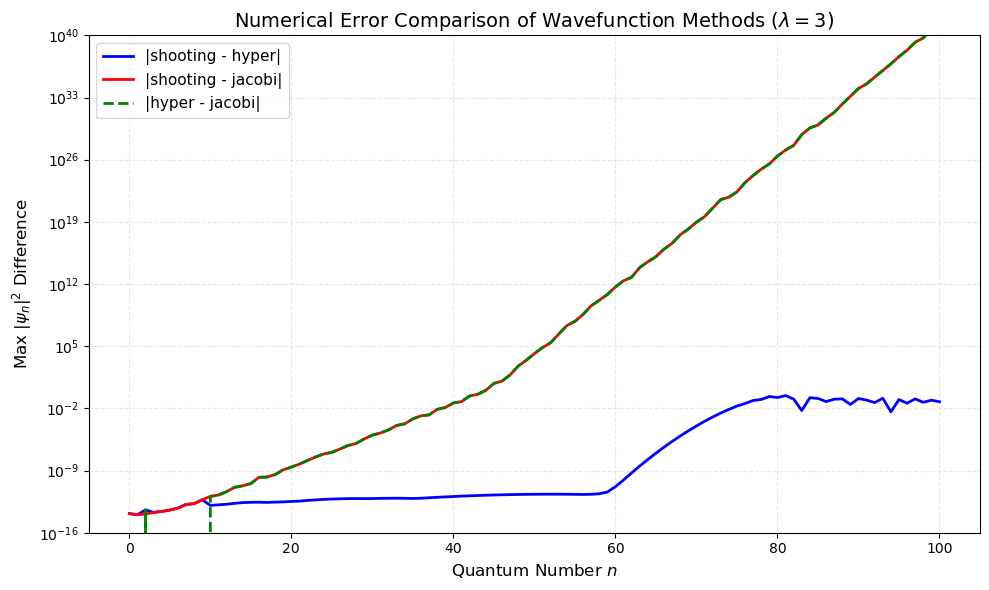

In [51]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

n_values = range(len(err_rh))
plt.semilogy(n_values, err_rh, 'b-', linewidth=2, label='|shooting - hyper|')
plt.semilogy(n_values, err_rj, 'r-', linewidth=2, label='|shooting - jacobi|')
plt.semilogy(n_values, err_hj, 'g--', linewidth=2, label='|hyper - jacobi|')

# Add grid for readability on log scale
plt.grid(True, which='both', alpha=0.3, linestyle='--')

# Labels and title
plt.xlabel('Quantum Number $n$', fontsize=12)
plt.ylabel('Max $|\psi_n|^2$ Difference', fontsize=12)
plt.title('Numerical Error Comparison of Wavefunction Methods ($\\lambda = 3$)', fontsize=14)
plt.legend(fontsize=11, loc='best')

# Set reasonable y-axis limits to show the full range
plt.ylim(1e-16, 1e40)

# Adjust layout and save
plt.tight_layout()

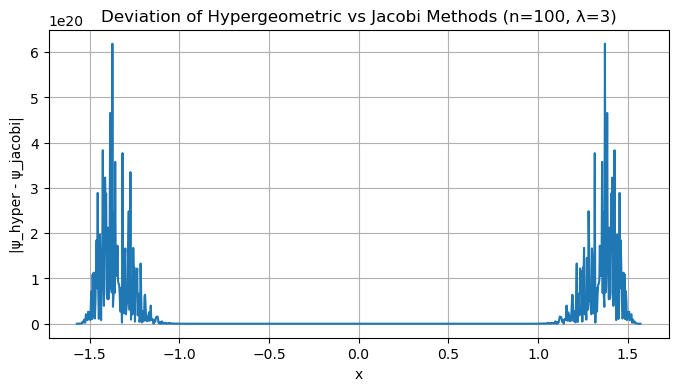

In [59]:
n = 100

# symbolic difference
diff_expr = (get_wavefunction_hyper(n) - get_wavefunction_jacobi(n)).subs(lam, 3)

# convert to numeric function
diff_fun = lambdify(x, diff_expr, 'mpmath')

xs = np.linspace(-np.pi/2 + 1e-6, np.pi/2 - 1e-6, 1000)

# evaluate difference
ys = [abs(diff_fun(i)) for i in xs]

# plot
plt.figure(figsize=(8,4))
plt.plot(xs, ys)
plt.xlabel('x')
plt.ylabel('|ψ_hyper - ψ_jacobi|')
plt.title('Deviation of Hypergeometric vs Jacobi Methods (n=100, λ=3)')
plt.grid(True)
plt.show()

In [ ]:
Integral(abs(get_wavefunction_hyper(100).subs(lam, 3))**2, (x, -pi/2, pi/2)).evalf()

## Time Evolution

In [6]:
def get_trig_eigenstate(n):
    En = n * (2 * lam + n)
    psi = get_wavefunction_jacobi(n)
    return (En, psi)

In [7]:
def change_basis_trigonometric(psi_0_expr, lam_val, max_n=10, precision=4):
    domain = np.linspace(-np.pi/2, np.pi/2, 10**precision)
    psi_0 = lambdify(x, psi_0_expr.subs(lam, lam_val), 'numpy')

    basis = []
    for n in tqdm(range(max_n + 1), desc="Spectral basis projection"):
        energy, psi_n_expr = get_trig_eigenstate(n)
        energy = float(energy.evalf(subs={lam: lam_val}))

        psi_n = lambdify(x, sp.conjugate(psi_n_expr.subs(lam, lam_val)), 'numpy')
        coeff = np.trapz(psi_n(domain) * psi_0(domain), x=domain)

        psi_n_forward = lambdify(x, psi_n_expr.subs(lam, lam_val), 'numpy')
        basis.append((energy, coeff, psi_n_forward))

    return basis, domain

def time_evolve_trigonometric(basis, domain, max_t, frames=200):
    def psi_t(t):
        acc = np.zeros_like(domain, dtype=complex)
        for energy, coeff, psi_n in basis:
            acc += coeff * psi_n(domain) * np.exp(-1j * energy * t)
        return acc

    results = []
    for t in tqdm(np.linspace(0, max_t, frames), desc="Spectral evolution"):
        psi_val = psi_t(t)
        x_expect = np.trapz(np.conjugate(psi_val)*domain*psi_val, x=domain).real
        results.append((t, psi_val, x_expect))
    return results

In [8]:
def trotter_time_evolve(psi0_vals, lam_val, max_t, frames=1000):
    N = len(psi0_vals)
    domain = np.linspace(-np.pi/2, np.pi/2, N)
    dx = domain[1] - domain[0]

    # Potential
    Vx = lam_val*(lam_val - 1) / (np.cos(domain)**2)

    # Fourier frequencies
    k = np.fft.fftfreq(N, d=dx) * 2*np.pi

    dt = max_t/frames
    psi = psi0_vals.copy()

    evolution = []
    for j in tqdm(range(frames+1), desc="Trotter evolution"):
        t = j*dt
        x_expect = np.trapz(np.conjugate(psi)*domain*psi, x=domain).real
        evolution.append((t, psi.copy(), x_expect))

        # Strang splitting (2nd order)
        psi = np.exp(-1j * Vx * (dt/2)) * psi
        psi = np.fft.ifft( np.exp(-1j * (k**2) * dt) * np.fft.fft(psi) )
        psi = np.exp(-1j * Vx * (dt/2)) * psi

    return evolution

In [9]:
def crank_nicolson(psi0_vals, lam_val, max_t, frames=1000):
    # Use slightly shrunken domain (avoid cos(x)=0 poles)
    eps = 1e-4
    N = len(psi0_vals)
    domain = np.linspace(-np.pi/2 + eps, np.pi/2 - eps, N)
    psi = psi0_vals.copy()

    dx = domain[1] - domain[0]
    N = len(domain)

    # Potential
    Vx = lam_val*(lam_val - 1)/np.cos(domain)**2

    # Second derivative operator: -d²/dx²
    main = 2.0*np.ones(N)/dx**2 + Vx
    off  = -1.0*np.ones(N-1)/dx**2

    H = spmat.diags([off, main, off], [-1,0,1], format='csc')

    dt = max_t/frames
    I = spmat.identity(N, format="csc")

    A = I + 1j*(dt/2)*H
    B = I - 1j*(dt/2)*H
    A_factor = spla.factorized(A)

    results = []

    for j in tqdm(range(frames+1), desc="CN"):
        t = j*dt

        # x expectation value
        x_expect = np.trapz(np.conjugate(psi)*domain*psi, x=domain).real
        results.append((t, psi.copy(), x_expect))

        rhs = B.dot(psi)
        psi = A_factor(rhs)

    return results


In [22]:
# psi_0 = (get_trig_eigenstate(0)[1] + get_trig_eigenstate(1)[1]+ get_trig_eigenstate(5)[1]) / sqrt(3)
x0 = 0.0 # displacement
psi_0 = simplify(exp(-(x+ x0)**2)*cos(x + x0))

In [23]:
lam_val = 3
max_n = 10
max_t = 10

basis, domain = change_basis_trigonometric(psi_0, lam_val=lam_val, max_n=max_n)
spectral = time_evolve_trigonometric(basis, domain, max_t=max_t, frames=200)

psi0_vals = sp.lambdify(x, psi_0.subs(lam, lam_val), 'numpy')(domain)

trotter = trotter_time_evolve(psi0_vals, lam_val=lam_val, max_t=max_t, frames=10000)

crank = crank_nicolson(psi0_vals, lam_val=lam_val, max_t=max_t, frames=10000)

CN: 100%|██████████| 10001/10001 [00:02<00:00, 4172.93it/s]


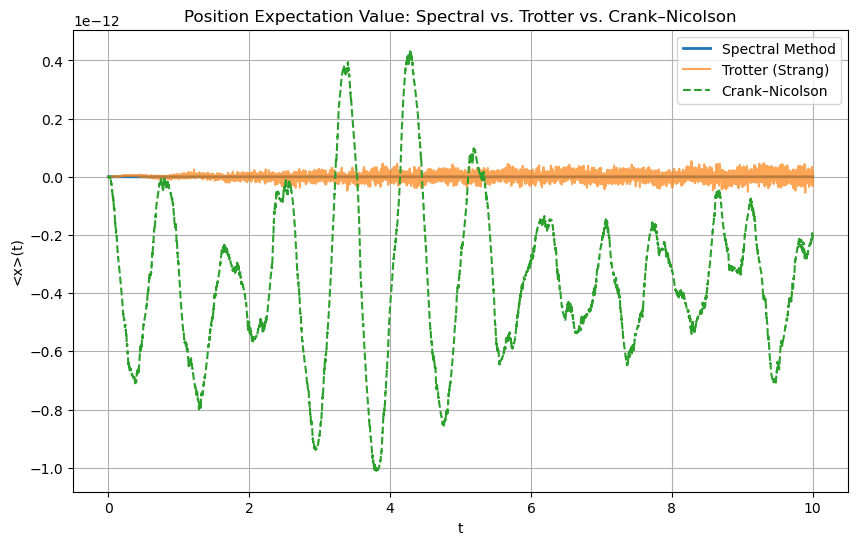

In [24]:
t_spec = [t for (t, psi, xexp) in spectral]
x_spec = [xexp for (t, psi, xexp) in spectral]

t_trot = [t for (t, psi, xexp) in trotter]
x_trot = [xexp for (t, psi, xexp) in trotter]

t_cn = [t for (t, psi, xexp) in crank]
x_cn = [xexp for (t, psi, xexp) in crank]

plt.figure(figsize=(10,6))
plt.plot(t_spec, x_spec, label="Spectral Method", linewidth=2)
plt.plot(t_trot, x_trot, label="Trotter (Strang)", alpha=0.7)
plt.plot(t_cn,   x_cn,   label="Crank–Nicolson", linestyle="--")

plt.xlabel("t")
plt.ylabel("<x>(t)")
plt.title("Position Expectation Value: Spectral vs. Trotter vs. Crank–Nicolson")
plt.legend()
plt.grid(True)
plt.show()